In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [293]:
beer_info = pd.read_csv("Datasets/beer_info.csv")
beer_reviews = pd.read_csv("Datasets/beer_reviews.csv")
review_details = pd.read_csv("Datasets/review_details.csv")

In [294]:
beer_info.shape

(242921, 4)

In [295]:
beer_reviews.shape

(1654502, 4)

In [296]:
review_details.shape

(1654502, 5)

In [297]:
beer_info.describe()

,beer_abv
count,204526.000000
mean,6.558847
std,2.197321
min,0.010000
25%,5.000000
50%,6.000000
75%,7.800000
max,57.700000


In [298]:
beer_info.isna().sum()

beer_name           0
brewery_name       12
beer_style          0
beer_abv        38395
dtype: int64

In [299]:
merged = pd.merge(beer_reviews, beer_info, on = "beer_name", how = "left")

In [300]:
merged.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name          966336
beer_style            966334
beer_abv             1000301
dtype: int64

In [301]:
import seaborn as sns

<Axes: ylabel='beer_abv'>

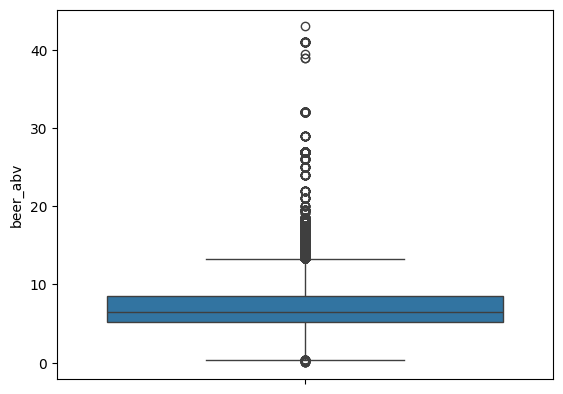

In [302]:
sns.boxplot(y = merged["beer_abv"])

In [303]:
import pandas as pd

col = merged["beer_abv"]

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged[(col < lower) | (col > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 12391


In [304]:
merged.head()


,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv
0,1,Sausa Weizen,stcules,1.5,NaN,NaN,NaN
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2
2,3,BLACK HORSE BLACK BEER,stcules,3.0,NaN,NaN,NaN
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0
4,5,Cauldron Dipa,johnmichaelsen,4.0,NaN,NaN,NaN


In [305]:
merged2= pd.merge(merged, review_details, on="review_id", how="left")

In [306]:
merged2.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,1,Sausa Weizen,stcules,1.5,NaN,NaN,NaN,2.0,2.5,1.5,1.5
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0,NaN,NaN,NaN,2.5,3.0,3.0,3.0
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,5,Cauldron Dipa,johnmichaelsen,4.0,NaN,NaN,NaN,4.5,4.0,4.5,4.0


In [307]:
merged2.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name          966336
beer_style            966334
beer_abv             1000301
aroma_score           145465
appearance_score           0
taste_score           135476
palate_score          231982
dtype: int64

In [308]:
df = merged2

In [309]:
df["brewery_name"] = df["brewery_name"].fillna("Unknown")

In [379]:
df.isna().sum()

review_id            0
beer_name            0
reviewer_username    0
overall_score        0
brewery_name         0
beer_style           0
beer_abv             0
aroma_score          0
appearance_score     0
taste_score          0
palate_score         0
dtype: int64

In [311]:
df["beer_style"] = df["beer_style"].fillna(df["beer_style"].mode()[0])

<Axes: >

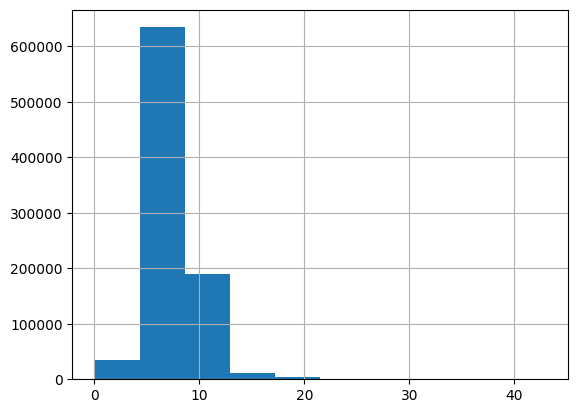

In [312]:
df["beer_abv"].hist()

In [378]:
df["beer_abv"] = df["beer_abv"].fillna(df["beer_abv"].median()) 

<Axes: >

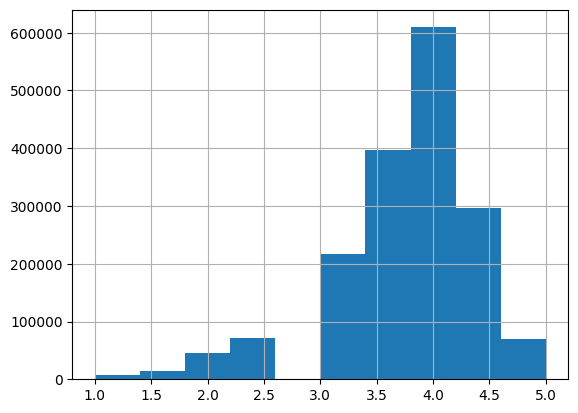

In [314]:
df["aroma_score"].hist()

In [315]:
df["aroma_score"] = df["aroma_score"].fillna(df["aroma_score"].median) 

In [316]:
df["aroma_score"] = pd.to_numeric(df["aroma_score"], errors="coerce")

In [317]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()

cols = ["overall_score", "aroma_score", "taste_score", "palate_score", "appearance_score"]

df[cols] = imputer.fit_transform(df[cols])

In [318]:
df = df.dropna(subset=["reviewer_username"])

In [319]:
df.isna().sum()

review_id            0
beer_name            0
reviewer_username    0
overall_score        0
brewery_name         0
beer_style           0
beer_abv             0
aroma_score          0
appearance_score     0
taste_score          0
palate_score         0
dtype: int64

In [320]:
df = df.drop_duplicates()

In [321]:
df.select_dtypes(include="object").columns

Index(['beer_name', 'reviewer_username', 'brewery_name', 'beer_style',
       'beer_abv'],
      dtype='object')

In [322]:
df["beer_abv"] = pd.to_numeric(df["beer_abv"], errors="coerce")

In [323]:
df.shape

(1872069, 11)

In [346]:
df.to_csv("beer.csv")

In [347]:
df.shape

(1872069, 11)

# outlier removal

#
# To find the best consistent beer style  

In [348]:
cols = ["beer_name", "reviewer_username", "brewery_name", "beer_style"]

for col in cols:
    df[col] = df[col].astype(str).str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

In [350]:
df["beer_style"].nunique()

104

In [351]:
style_stats = df.groupby("beer_style")["overall_score"].agg(["mean","std","count"])
#--------------------------------------------------------------------
style_stats = style_stats[style_stats["count"] >= 1000]
best_styles = style_stats.sort_values(
    by=["mean","std"],
    ascending=[False, True]
)

print(best_styles.head(10))

                                      mean       std  count
beer_style                                                 
american wild ale                 4.106377  0.640145  10138
gueuze                            4.099912  0.612816   3407
quadrupel (quad)                  4.073763  0.619037  10581
american double / imperial stout  4.040446  0.654755  30296
keller bier / zwickel bier        4.039050  0.617981   1277
russian imperial stout            4.030360  0.626294  32182
weizenbock                        4.023062  0.583948   5555
eisbock                           4.008306  0.612844   1561
american double / imperial ipa    3.998384  0.634415  49215
rye beer                          3.988733  0.589706   5605


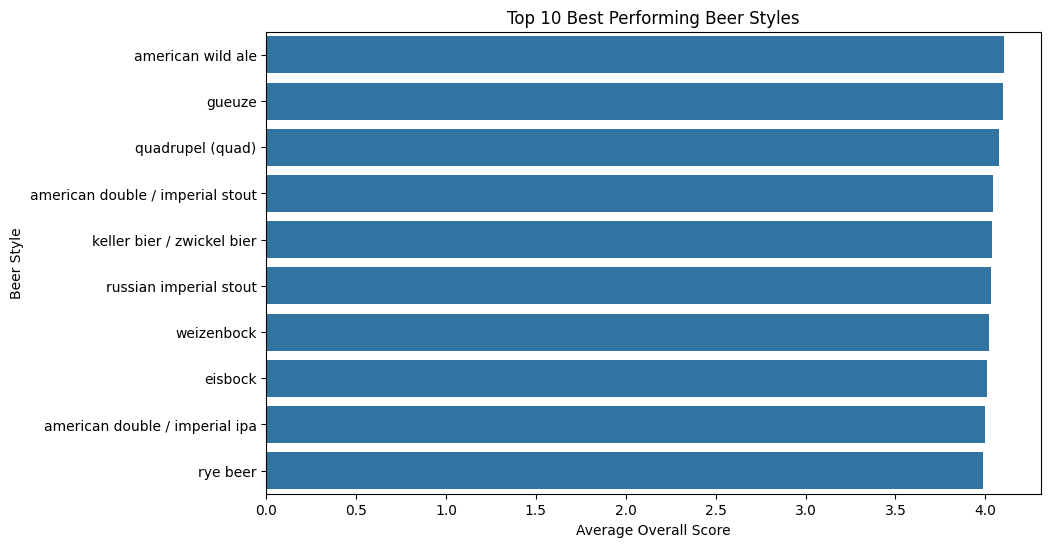

In [352]:
# get top 10 best styles
top10 = best_styles.head(10).reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="mean",
    y="beer_style"
)

plt.title("Top 10 Best Performing Beer Styles")
plt.xlabel("Average Overall Score")
plt.ylabel("Beer Style")

plt.show()

#
# To find underperforming styles

In [353]:
overall_mean = df["overall_score"].mean()
print(overall_mean)

3.8180389055661097


In [354]:
style_stats["difference_from_avg"] = style_stats["mean"] - overall_mean

In [355]:
underperforming = style_stats[style_stats["difference_from_avg"] < 0]

In [356]:
underperforming = underperforming[underperforming["count"] >= 1000]

In [357]:
underperforming.sort_values("difference_from_avg").head(10)

,mean,std,count,difference_from_avg
beer_style,,,,
american malt liquor,2.659264,1.024866,2148,-1.158775
light lager,2.666597,1.033940,7832,-1.151442
euro strong lager,2.935897,0.904210,1361,-0.882142
american adjunct lager,2.999071,0.927014,17370,-0.818968
chile beer,3.055293,1.131397,1127,-0.762746
japanese rice lager,3.124645,0.787493,1069,-0.693394
euro pale lager,3.229645,0.799807,9604,-0.588394
euro dark lager,3.408678,0.739324,2609,-0.409361
american pale lager,3.410136,0.812472,5082,-0.407903


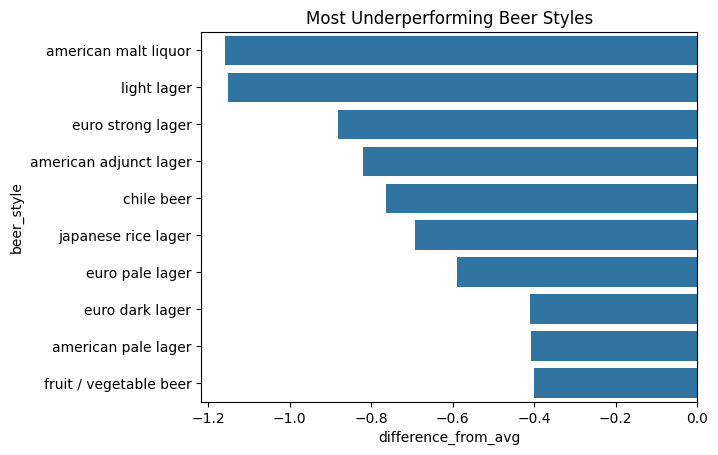

In [358]:
sns.barplot(
    data=underperforming.sort_values("difference_from_avg").head(10),
    x="difference_from_avg",
    y=underperforming.sort_values("difference_from_avg").head(10).index
)

plt.title("Most Underperforming Beer Styles")
plt.show()

#
## Objective 2 - Determining which sensory feature most influences a beer’s overall rating.

In [359]:
sensory_cols = ["aroma_score", "taste_score", "palate_score", "appearance_score"]

corr = df[sensory_cols + ["overall_score"]].corr()

corr["overall_score"].sort_values(ascending=False)

overall_score       1.000000
taste_score         0.803796
palate_score        0.724984
aroma_score         0.630992
appearance_score    0.504775
Name: overall_score, dtype: float64

In [360]:
brewery_size = df.groupby("brewery_name").size().sort_values(ascending=False)

brewery_size.head(20)

brewery_name
unknown                               966106
boston beer company (samuel adams)     24003
dogfish head brewery                   20898
stone brewing co.                      20151
sierra nevada brewing co.              17512
bell's brewery, inc.                   14618
rogue ales                             12894
founders brewing company               11395
victory brewing company                11066
anheuser-busch                          9635
southern tier brewing company           9533
lagunitas brewing company               9367
avery brewing company                   9330
great divide brewing company            9308
unibroue                                8597
three floyds brewing co. & brewpub      8312
new belgium brewing                     8261
brooklyn brewery                        8217
tröegs brewing company                  7117
weyerbacher brewing co.                 7106
dtype: int64

#
### Objective 3 - comparing the brewery size and reviews

Objective 5- 

In [361]:
X = df[
    ["aroma_score", "taste_score", "palate_score",
     "appearance_score", "beer_abv"]]
y = df["overall_score"]

In [362]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [363]:
print(X_train.dtypes)

aroma_score         float64
taste_score         float64
palate_score        float64
appearance_score    float64
beer_abv            float64
dtype: object


In [364]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [365]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

print(importance)

taste_score         0.894645
palate_score        0.062736
appearance_score    0.016116
aroma_score         0.014283
beer_abv            0.012219
dtype: float32


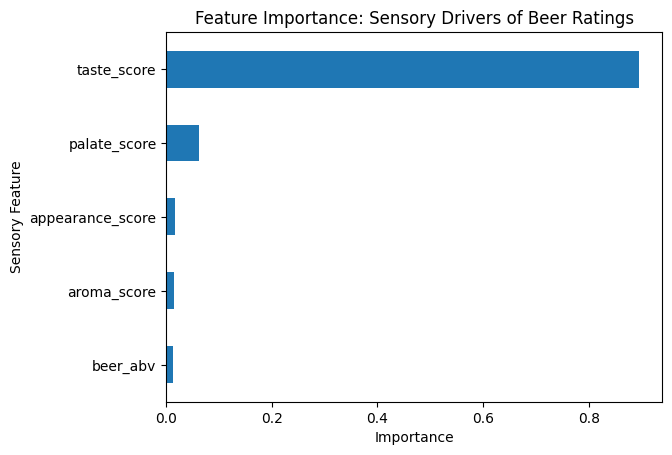

In [366]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance: Sensory Drivers of Beer Ratings")
plt.xlabel("Importance")
plt.ylabel("Sensory Feature")

plt.show()

In [367]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error


y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7384252246652689
RMSE: 0.36477575201980633
MAE: 0.2575876459031898


In [368]:
top_beers = df[df["overall_score"] >= 4.5]

top_profile = top_beers[
    ["aroma_score","taste_score","palate_score","appearance_score"]
].mean()

top_profile

aroma_score         4.171858
taste_score         4.375748
palate_score        4.241841
appearance_score    4.165567
dtype: float64

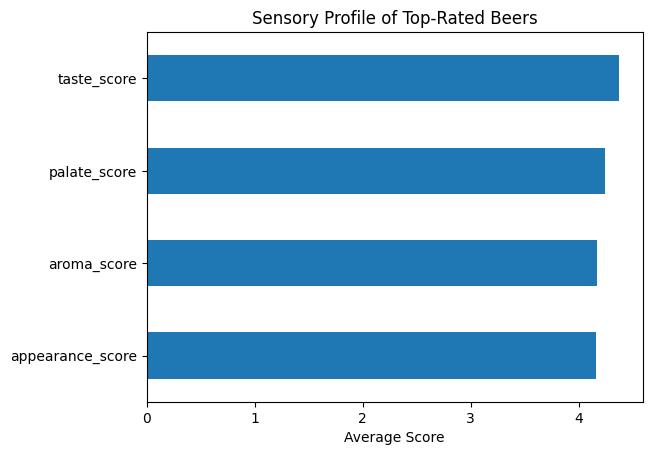

In [369]:
top_profile.sort_values().plot(kind="barh")

plt.title("Sensory Profile of Top-Rated Beers")
plt.xlabel("Average Score")
plt.show()

# Objective 6

In [406]:
import pandas as pd

beer_profiles = df.groupby("beer_name").agg({
    "aroma_score": "mean",
    "appearance_score": "mean",
    "taste_score": "mean",
    "palate_score": "mean",
    "beer_abv": "mean",
    "overall_score": "mean",
    "beer_style": "first",
    "review_id": "count"
}).rename(columns={"review_id": "review_count"}).reset_index()

In [407]:
beer_profiles = beer_profiles[beer_profiles["review_count"] > 50]
beer_profiles = beer_profiles.reset_index(drop=True)

In [408]:
from sklearn.impute import SimpleImputer

features = [
    "aroma_score",
    "appearance_score",
    "taste_score",
    "palate_score",
    "beer_abv"
]

imputer = SimpleImputer(strategy="mean")
beer_profiles[features] = imputer.fit_transform(beer_profiles[features])

In [409]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(beer_profiles[features])

In [410]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)

In [411]:
print(len(beer_profiles))
print(similarity_matrix.shape)

5676
(5676, 5676)


In [412]:
def recommend_beers(beer_name, n=5):

    matches = beer_profiles[
        beer_profiles["beer_name"].str.contains(beer_name, case=False, na=False)
    ]

    if matches.empty:
        print("Beer not found in dataset.")
        return

    idx = matches.index[0]

    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    scores = scores[1:n+1]

    beer_indices = [i[0] for i in scores]

    return beer_profiles.iloc[beer_indices][
        ["beer_name", "beer_style", "beer_abv", "overall_score"]
    ]

In [413]:
recommend_beers("guinness")

,beer_name,beer_style,beer_abv,overall_score
3752,peak organic amber ale,american amber / red ale,5.904412,3.609296
510,belhaven best,american ipa,4.929167,3.532735
3250,moling's traditional red ale,american ipa,5.374419,3.564448
5635,young's winter warmer,winter warmer,5.695565,3.629495
4410,schöfferhofer hefeweizen,hefeweizen,5.710526,3.641774


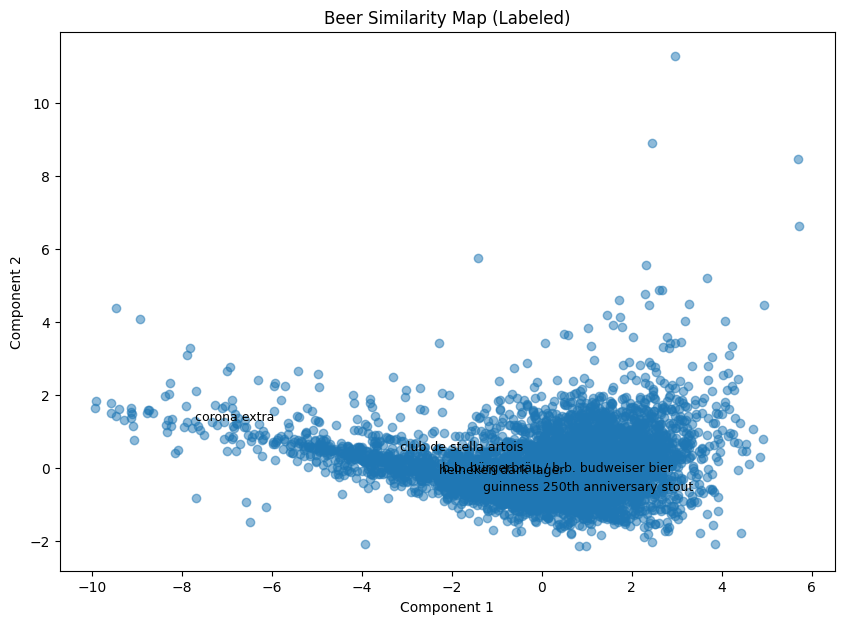

In [415]:
important_beers = ["guinness", "heineken", "budweiser", "corona", "stella"]

plt.figure(figsize=(10,7))
plt.scatter(beer_map[:,0], beer_map[:,1], alpha=0.5)

for beer in important_beers:
    
    match = beer_profiles[beer_profiles["beer_name"].str.contains(beer, case=False, na=False)]
    
    if not match.empty:
        idx = match.index[0]
        
        plt.text(
            beer_map[idx,0],
            beer_map[idx,1],
            beer_profiles.iloc[idx]["beer_name"],
            fontsize=9
        )

plt.title("Beer Similarity Map (Labeled)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [416]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1","PC2"]
)

print(loadings)

     aroma_score  appearance_score  taste_score  palate_score  beer_abv
PC1     0.482723          0.466869     0.483310      0.484343  0.284315
PC2    -0.097324         -0.168580    -0.159397     -0.143314  0.957164


In [417]:
recommend_beers("guinness")

,beer_name,beer_style,beer_abv,overall_score
3752,peak organic amber ale,american amber / red ale,5.904412,3.609296
510,belhaven best,american ipa,4.929167,3.532735
3250,moling's traditional red ale,american ipa,5.374419,3.564448
5635,young's winter warmer,winter warmer,5.695565,3.629495
4410,schöfferhofer hefeweizen,hefeweizen,5.710526,3.641774
